In [2]:


import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier




DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable22.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["date"])

# Clean supplier names
df["supplier"] = (
    df["supplier"]
    .astype(str)
    .str.strip()
    .str.replace(",", "", regex=False)
    .str.upper()
)




# Recommended threshold for rare-event modeling
THRESHOLD = 0.6

df["high_disruption_label"] = (
    df["high_disruption_p"] >= THRESHOLD
).astype(int)

print("\nOverall Class Distribution:")
print(df["high_disruption_label"].value_counts())





X = df[[
    "supplier",
    "kg_score",
    "twitter_alert",
    "weather_risk",
    "economic_risk",
    "geo_risk",
    "tech_risk",
    "downtime_hours",
]]

y = df["high_disruption_label"]


# ==========================================================
# 5️⃣ Train-Test Split (Safe)
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,        # 80% train, 20% test
    stratify=y,
    random_state=42,
)

print("\nTraining Class Distribution:")
print(y_train.value_counts())





num_cols = ["kg_score", "downtime_hours"]

cat_cols = ["supplier"]

pass_cols = [
    "twitter_alert",
    "weather_risk",
    "economic_risk",
    "geo_risk",
    "tech_risk",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("onehot", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough"
)



def build_and_evaluate(model, name):
    
    pipe = Pipeline([
        ("pre", preprocessor),
        ("clf", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]


    print(f"\n==============================")
    print(f"Model: {name}")
    print(f"==============================")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=3))

    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

    return pipe


# ==========================================================
# 8️⃣ Train Models
# ==========================================================

log_model = build_and_evaluate(
    LogisticRegression(max_iter=1000, random_state=42),
    "Logistic Regression"
)

rf_model = build_and_evaluate(
    RandomForestClassifier(n_estimators=100, random_state=42),
    "Random Forest"
)

gb_model = build_and_evaluate(
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"
)


# ==========================================================
# 9️⃣ Optional: Hyperparameter Tuning (Random Forest)
# ==========================================================

param_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth": [None, 5, 10]
}

grid = GridSearchCV(
    Pipeline([
        ("pre", preprocessor),
        ("clf", RandomForestClassifier(random_state=42))
    ]),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nBest Random Forest Parameters:")
print(grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}")


Overall Class Distribution:
high_disruption_label
1    416
0    184
Name: count, dtype: int64

Training Class Distribution:
high_disruption_label
1    333
0    147
Name: count, dtype: int64

Model: Logistic Regression

Confusion Matrix:
[[30  7]
 [ 4 79]]

Classification Report:
              precision    recall  f1-score   support

           0      0.882     0.811     0.845        37
           1      0.919     0.952     0.935        83

    accuracy                          0.908       120
   macro avg      0.900     0.881     0.890       120
weighted avg      0.907     0.908     0.907       120

ROC-AUC: 0.983

Model: Random Forest

Confusion Matrix:
[[32  5]
 [ 7 76]]

Classification Report:
              precision    recall  f1-score   support

           0      0.821     0.865     0.842        37
           1      0.938     0.916     0.927        83

    accuracy                          0.900       120
   macro avg      0.879     0.890     0.884       120
weighted avg      0.9

In [3]:
# ─── Supplier‐level Ranking by Predicted Disruption Risk ──────────────────────
from sklearn.pipeline import Pipeline

# 1) Rebuild the full‐data pipeline + best classifier (here: the tuned RandomForest)
best_rf = GradientBoostingClassifier(
    n_estimators=grid.best_params_['clf__n_estimators'],
    max_depth=  grid.best_params_['clf__max_depth'],
    random_state=42
)
full_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", best_rf)
])
# 2) Fit on all available data
full_pipe.fit(X, y)

# 3) Score every row → disruption probability
df["pred_prob"] = full_pipe.predict_proba(X)[:,1]

# 4) Average per supplier, sort descending
supplier_ranking = (
    df
    .groupby("supplier")["pred_prob"]
    .mean()
    .reset_index(name="avg_disruption_prob")
    .sort_values("avg_disruption_prob", ascending=False)
    .reset_index(drop=True)
)

print("=== Supplier Ranking by Mean Predicted Disruption Risk ===")
print(supplier_ranking.head(10))


=== Supplier Ranking by Mean Predicted Disruption Risk ===
  supplier  avg_disruption_prob
0      JHH             0.949988
1     YAHO             0.949988
2       YG             0.916657
3      ARC             0.766661
4      KMP             0.733331
5      GHM             0.699999
6     SZHA             0.633335
7      SCT             0.450011
8     DMEC             0.416679
9      ZSM             0.416679


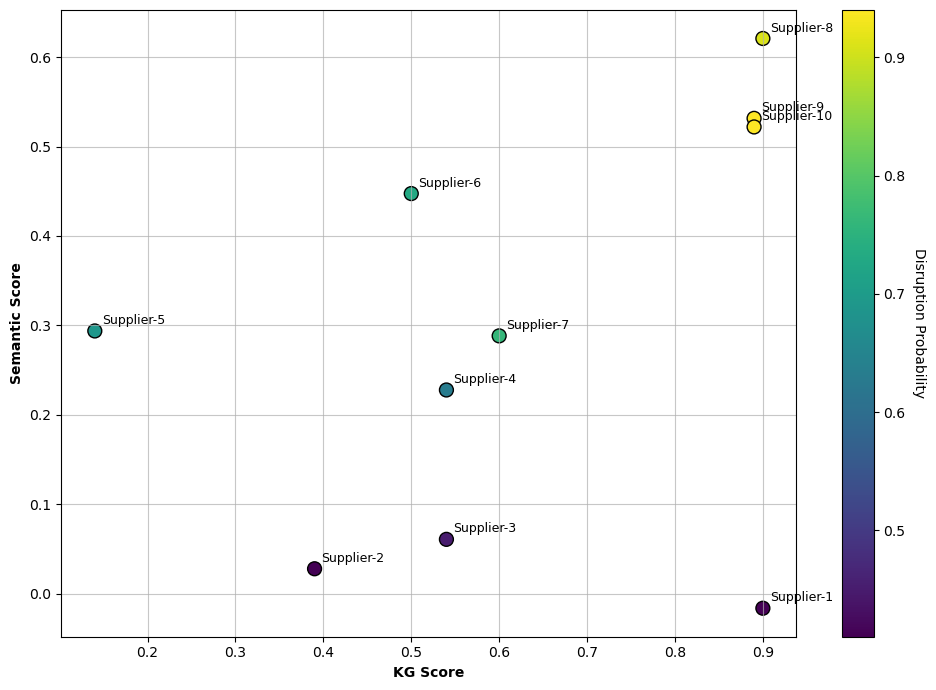

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create the dataset based on image_64185e.png
data = {
    'Supplier': ['Supplier-1', 'Supplier-2', 'Supplier-3', 'Supplier-4', 'Supplier-5', 
                 'Supplier-6', 'Supplier-7', 'Supplier-8', 'Supplier-9', 'Supplier-10'],
    'KG_Score': [0.9, 0.39, 0.54, 0.54, 0.14, 0.5, 0.6, 0.9, 0.89, 0.89],
    'Semantic_Score': [-0.01623, 0.0279, 0.0608, 0.2278, 0.2938, 0.4474, 0.2883, 0.6208, 0.5315, 0.5219],
    'Disruption_Prob': [0.41, 0.41, 0.45, 0.63, 0.69, 0.73, 0.76, 0.91, 0.94, 0.94]
}

df = pd.DataFrame(data)

# 2. Setup the plot
plt.figure(figsize=(10, 7))

# 3. Create scatter plot
# x = KG Score, y = Semantic Score, c = Disruption Probability (for color)
scatter = plt.scatter(df['KG_Score'], df['Semantic_Score'], 
                      c=df['Disruption_Prob'], cmap='viridis', 
                      s=100, edgecolors='black', linewidth=1)

# 4. Add labels for each supplier point
for i, txt in enumerate(df['Supplier']):
    plt.annotate(txt, (df['KG_Score'][i], df['Semantic_Score'][i]), 
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

# 5. Formatting the chart to match image_641b60.png
plt.xlabel('KG Score', fontweight='bold')
plt.ylabel('Semantic Score', fontweight='bold')
plt.grid(True, linestyle='-', alpha=0.7)

# Add color bar
cbar = plt.colorbar(scatter)
cbar.set_label('Disruption Probability', rotation=270, labelpad=15)

# Adjust layout and show
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# === 1. Load dataset ===
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable22.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.6).astype(int)

# === 2. Features and target ===
features = [
    "supplier", "kg_score", "Em_Score",
    "twitter_alert", "weather_risk", "economic_risk",
    "geo_risk", "tech_risk", "downtime_hours"
]
X = df[features]
y = df["high_disruption_label"]

# === 3. Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=65
)

# === 4. Preprocessing ===
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["kg_score", "Em_Score", "downtime_hours"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["supplier"])
], remainder="passthrough")

# Fit-transform preprocessing for train/test
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

# === 5. Define models ===
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=45),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=45),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=45),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=95, eval_metric="logloss"),
}

# === 6. Train and evaluate ===
for name, model in models.items():
    model.fit(X_train_trans, y_train)
    y_proba = model.predict_proba(X_test_trans)[:, 1]

    mae = mean_absolute_error(y_test, y_proba)
    mse = mean_squared_error(y_test, y_proba)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_proba)

    print(f"\n=== {name} ===")
    print(f"MAE     : {mae:.6f}")
    print(f"MSE     : {mse:.6f}")
    print(f"RMSE    : {rmse:.6f}")
    print(f"R² Score: {r2:.6f}")


=== Logistic Regression ===
MAE     : 0.063427
MSE     : 0.019401
RMSE    : 0.139288
R² Score: 0.909028

=== Random Forest ===
MAE     : 0.087000
MSE     : 0.030307
RMSE    : 0.174089
R² Score: 0.857889

=== Gradient Boosting ===
MAE     : 0.038889
MSE     : 0.025248
RMSE    : 0.158896
R² Score: 0.881611

=== XGBoost ===
MAE     : 0.029343
MSE     : 0.016002
RMSE    : 0.126497
R² Score: 0.924968


In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# classifiers
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier

import joblib   # <-- for model persistence

# ─── 1) Load your data ───────────────────────────────────────────────────────
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable22.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

# ─── 2) Binarize your continuous target ─────────────────────────────────────
# threshold at 0.5 (or whatever you chose)
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.5).astype(int)

# ─── 3) Define features X and label y ────────────────────────────────────────
X = df[[
    "supplier",
    "kg_score",
    "Em_Score",
    "twitter_alert",
    "weather_risk",
    "economic_risk",
    "geo_risk",
    "tech_risk",
    "downtime_hours",
]]
y = df["high_disruption_label"]

# ─── 4) Train / test split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.8,      # e.g. 60/40 split
    stratify=y,
    random_state=42,
)

# ─── 5) Build preprocessing pipeline ─────────────────────────────────────────
num_cols = ["kg_score", "downtime_hours"]
cat_cols = ["supplier"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num",   StandardScaler(),  num_cols),
        ("onehot", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough"
)

# ─── 6) Helper to build, train, evaluate ──────────────────────────────────────
def build_and_save(model, name, filename):
    pipe = Pipeline([("pre", preprocessor), ("clf", model)])
    pipe.fit(X_train, y_train)

    # Evaluate
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    print(f"\n=== {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=3))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

    # Save to disk
    joblib.dump(pipe, filename)
    print(f"☑️  Saved {name} pipeline to {filename}")

# ─── 7) Train, evaluate & save ───────────────────────────────────────────────
build_and_save(LogisticRegression(max_iter=1000, random_state=42),
               "Logistic Regression", "logreg_supplier_disruption.joblib")

build_and_save(RandomForestClassifier(n_estimators=100, random_state=42),
               "Random Forest", "rf_supplier_disruption.joblib")

build_and_save(GradientBoostingClassifier(n_estimators=100, random_state=42),
               "Gradient Boosting", "gb_supplier_disruption.joblib")

# ─── 8) Hyper‐parameter search on RF & save best ──────────────────────────────
param_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth":    [None, 5, 10]
}
grid = GridSearchCV(
    Pipeline([("pre", preprocessor), ("clf", RandomForestClassifier(random_state=42))]),
    param_grid, cv=3, scoring="roc_auc", n_jobs=-1
)
grid.fit(X_train, y_train)

print("\n=== RF Grid Search Best ===")
print(grid.best_params_, f"ROC-AUC={grid.best_score_:.3f}")

# Save the best‐found pipeline (GridSearchCV wraps the pipeline)
joblib.dump(grid.best_estimator_, "rf_grid_supplier_disruption.joblib")
print("☑️  Saved tuned Random Forest pipeline to rf_grid_supplier_disruption.joblib")


=== Logistic Regression ===
Confusion Matrix:
[[ 73  17]
 [  8 382]]

Classification Report:
              precision    recall  f1-score   support

           0      0.901     0.811     0.854        90
           1      0.957     0.979     0.968       390

    accuracy                          0.948       480
   macro avg      0.929     0.895     0.911       480
weighted avg      0.947     0.948     0.947       480

ROC-AUC: 0.978
☑️  Saved Logistic Regression pipeline to logreg_supplier_disruption.joblib

=== Random Forest ===
Confusion Matrix:
[[ 67  23]
 [ 15 375]]

Classification Report:
              precision    recall  f1-score   support

           0      0.817     0.744     0.779        90
           1      0.942     0.962     0.952       390

    accuracy                          0.921       480
   macro avg      0.880     0.853     0.865       480
weighted avg      0.919     0.921     0.919       480

ROC-AUC: 0.976
☑️  Saved Random Forest pipeline to rf_supplier_disruption

In [13]:
import pandas as pd
import numpy as np

# Load dataset using the corrected path
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable22.csv"

df = pd.read_csv(DATA_PATH)

# Display the first 5 rows to verify the load
print(df.head())

df.head()

df["high_disruption_label"] = (df["high_disruption_p"] >= 0.6).astype(int)

# Feature set (edit if needed)
X = df[[
    "kg_score",
    "Em_Score",
    "twitter_alert",
    "weather_risk",
    "economic_risk",
    "geo_risk",
    "tech_risk",
    "downtime_hours",
   
]]

y = df["high_disruption_label"]
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        C=1.0,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=65,
        eval_metric="logloss",
        use_label_encoder=False
    )
}

results = []

for name, model in models.items():
    
    acc = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
    f1 = cross_val_score(model, X, y, cv=skf, scoring="f1")
    roc = cross_val_score(model, X, y, cv=skf, scoring="roc_auc")
    
    results.append({
        "Model": name,
        "Accuracy Mean": np.mean(acc),
        "Accuracy Std": np.std(acc),
        "F1 Mean": np.mean(f1),
        "F1 Std": np.std(f1),
        "ROC-AUC Mean": np.mean(roc),
        "ROC-AUC Std": np.std(roc)
    })

cv_results = pd.DataFrame(results).sort_values("ROC-AUC Mean", ascending=False)

print("\n📊 5-Fold Cross Validation Results:\n")
print(cv_results)

       date supplier  kg_score  Em_Score  twitter_alert  weather_risk  \
0  1/1/2025      JHH  0.442711  0.552985              1             0   
1  1/2/2025      JHH  0.599101  0.509835              0             1   
2  1/3/2025      JHH  0.372080  0.532829              0             0   
3  1/4/2025      JHH  1.167822  0.571556              0             0   
4  1/5/2025      JHH  0.071730  0.591891              1             1   

   economic_risk  geo_risk  tech_risk  downtime_hours  high_disruption_p  
0              1         0          0             5.1           0.866602  
1              0         0          0             7.2           0.847657  
2              0         0          0             1.0           0.746924  
3              0         0          0             1.8           0.960245  
4              0         0          0             7.7           0.752698  


C:\Users\srahman3\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:04:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\srahman3\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:04:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\srahman3\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:04:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\srahman3\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:04:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 


📊 5-Fold Cross Validation Results:

                 Model  Accuracy Mean  Accuracy Std   F1 Mean    F1 Std  \
3              XGBoost       0.971667      0.015456  0.979664  0.011188   
1        Random Forest       0.961667      0.018708  0.972595  0.013182   
2    Gradient Boosting       0.968333      0.013333  0.977196  0.009530   
0  Logistic Regression       0.956667      0.020683  0.969450  0.014452   

   ROC-AUC Mean  ROC-AUC Std  
3      0.996451     0.002233  
1      0.996088     0.002887  
2      0.994691     0.003299  
0      0.989085     0.007955  


In [7]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import networkx as nx
import matplotlib.pyplot as plt

# === Load and rename ===
df = pd.read_excel(
    r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\supplier list 100.xlsx"
)
df = df.rename(columns={
    "Company": "Supplier",
})

# === Define criteria patterns (now includes delivery & security explicitly) ===
criteria_patterns = {
    "delivery": ["delivery", "fast delivery", "timely delivery"],
    "quality": ["quality", "high quality", "product quality"],
    "security": ["security", "secure", "cybersecurity", "compliance"],
    "pricing": ["price", "cost", "pricing", "low cost"],
    "lead": ["lead time", "lead-time", "leadtime"],
    "sustainability": ["sustainability", "green", "eco", "environment"]
}

# === Robots.txt Check ===
def allowed_to_scrape(url):
    try:
        base_url = '/'.join(url.split('/')[:3]) + '/robots.txt'
        parser = rp.RobotFileParser()
        parser.set_url(base_url)
        parser.read()
        return parser.can_fetch("*", url)
    except:
        return False
# === Criteria weights ===
criteria_weights = {
    "sustainability": 0.50,
    "reliability": 0.30,   # reliability weight remains in KG
    "iso_cert": 0.06,
    "lead": 0.05,
    "quality": 0.04,
    "price": 0.05
}

def score_website(url):
    """Fetch text from website and check keywords."""
    try:
        r = requests.get(url, timeout=10)
        text = BeautifulSoup(r.text, "html.parser").get_text(" ").lower()
    except Exception:
        text = ""
    return {crit: int(any(pat in text for pat in pats))
            for crit, pats in criteria_patterns.items()}

# === Build full KG ===
G_full = nx.DiGraph()
records = []

for _, row in df.iterrows():
    sup  = row["Supplier"]
    site = row["Website"]
    scores = score_website(site)
    
    # Weighted KG score (based on matched criteria)
    weighted_score = sum(scores.get(c, 0) * criteria_weights.get(c, 0.05) for c in scores)
    
    rec = {"Supplier": sup, "Weighted KG Score": weighted_score}
    rec.update(scores)  # adds delivery, quality, security, pricing, lead, sustainability
    records.append(rec)

    # Add edges
    for crit, flag in scores.items():
        if flag:
            G_full.add_edge(crit, sup, label=f"associated_with_{sup}")

           ## G_full.add_edge(sup, crit, label=f"has_{crit}")

# === PageRank Integration ===
pagerank_scores = nx.pagerank(G_full)
for rec in records:
    rec["PageRank"] = pagerank_scores.get(rec["Supplier"], 0)

# === Final KG Score ===
for rec in records:
    rec["Final KG Score"] = rec["Weighted KG Score"] + rec["PageRank"]

# === Rank and display with all criteria columns ===
ranked = pd.DataFrame(records).sort_values("Final KG Score", ascending=False).reset_index(drop=True)

cols_to_display = ["Supplier", "delivery", "quality", "security", "pricing", "lead", "sustainability",
                   "Weighted KG Score", "PageRank", "Final KG Score"]

print("\n🏆 Top 10 Suppliers by Weighted KG Score + PageRank (with detailed criteria scores):")
print(ranked[cols_to_display].head(10).to_string(index=False))



🏆 Top 10 Suppliers by Weighted KG Score + PageRank (with detailed criteria scores):
                                          Supplier  delivery  quality  security  pricing  lead  sustainability  Weighted KG Score  PageRank  Final KG Score
                                         DME China         1        1         1        0     0               1               0.64  0.053370        0.693370
               Haitian Plastics Machinery (Ningbo)         1        0         0        1     0               1               0.60  0.052194        0.652194
                     Ningbo Durama Precision Mould         1        0         1        0     0               1               0.60  0.049751        0.649751
               Shenzhen Yili Die & Mould Co., Ltd.         1        0         1        0     0               1               0.60  0.049751        0.649751
                 Kunshan Rich-Laser Mold Co., Ltd.         1        0         1        0     0               1               0.60  0.04